In [2]:
import pandas as pd

df = pd.read_csv("../data/DataAnalyst.csv")

# Clean column names
df.columns = df.columns.str.lower()

# Remove useless column
df = df.drop(columns=["unnamed: 0"])

# Drop missing descriptions
df = df.dropna(subset=["job description"])

df.head()

,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [3]:
skills_keywords = [
    "python", "sql", "excel", "tableau", "power bi",
    "r", "machine learning", "deep learning",
    "aws", "azure", "spark", "hadoop"
]

skills_count = {skill: 0 for skill in skills_keywords}

for desc in df["job description"]:
    desc = desc.lower()
    for skill in skills_keywords:
        if skill in desc:
            skills_count[skill] += 1

skills_df = pd.Series(skills_count).sort_values(ascending=False)
print(skills_df)

r                   2252
sql                 1389
excel               1354
python               637
tableau              620
aws                  275
power bi             180
machine learning     180
hadoop               136
spark                 89
azure                 64
deep learning         11
dtype: int64


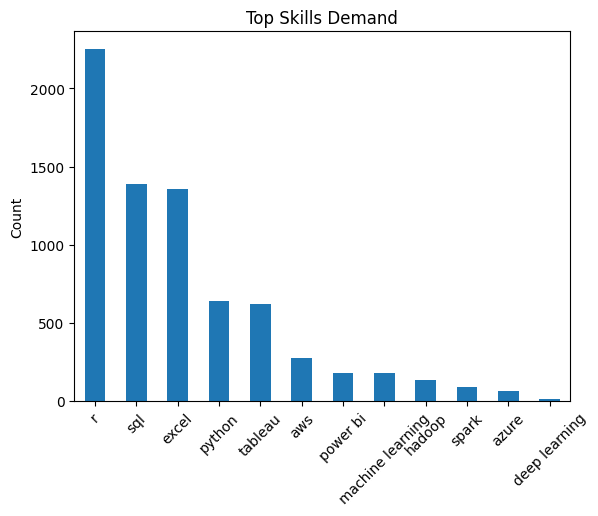

In [4]:
import matplotlib.pyplot as plt

skills_df.plot(kind='bar')
plt.title("Top Skills Demand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

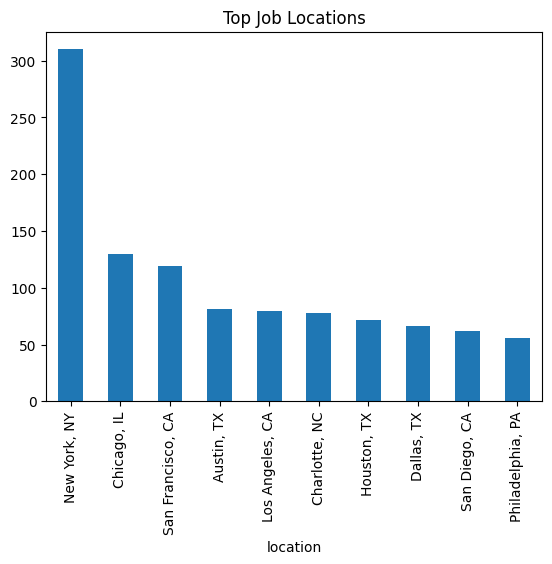

In [5]:
location_counts = df["location"].value_counts().head(10)

location_counts.plot(kind='bar')
plt.title("Top Job Locations")
plt.show()

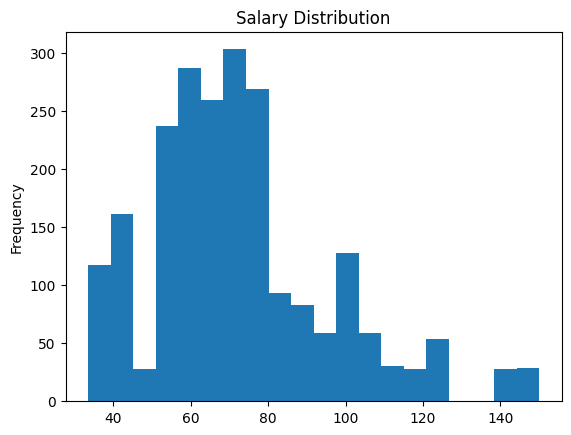

In [6]:
import re

def extract_salary(s):
    if isinstance(s, str):
        nums = re.findall(r'\d+', s)
        if len(nums) >= 2:
            return (int(nums[0]) + int(nums[1])) / 2
    return None

df["avg_salary"] = df["salary estimate"].apply(extract_salary)

df["avg_salary"].dropna().plot(kind='hist', bins=20)
plt.title("Salary Distribution")
plt.show()

In [8]:
import streamlit as st
import pandas as pd

df = pd.read_csv("../data/DataAnalyst.csv")
df.columns = df.columns.str.lower()

st.title("📊 Job Market Analyzer")

st.subheader("Top Job Locations")
st.bar_chart(df["location"].value_counts().head(10))

st.subheader("Top Job Titles")
st.bar_chart(df["job title"].value_counts().head(10))

2026-04-17 10:11:19.862 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 10:11:19.880 
  command:

    streamlit run /Users/alvinsaju/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-17 10:11:19.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 10:11:19.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 10:11:19.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 10:11:19.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 10:11:19.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 10:11:20.409 Threa

DeltaGenerator()